# Relatório de Análise Preditiva de Falhas em Máquinas (apenas o conjunto de testes)

### 1. Modelagem Preditiva: Preparação dos Dados e Treinamento do Modelo

Vamos usar as variáveis existentes `X_train`, `X_test`, `y_train`, `y_test` e treinar um modelo de classificação. Para isso, precisaremos pré-processar as variáveis categóricas.

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identificar colunas categóricas e numéricas no X_train
categorical_features = X_train.select_dtypes(include=['object']).columns
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns

# Criar o pré-processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Definir o modelo de classificação (RandomForestClassifier)
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(random_state=42))])

# Treinar o modelo
model.fit(X_train, y_train)

print("Modelo de RandomForestClassifier treinado com sucesso!")

Modelo de RandomForestClassifier treinado com sucesso!


O modelo de classificação `RandomForestClassifier` foi treinado com sucesso utilizando um `ColumnTransformer` para pré-processar as features numéricas (passthrough) e categóricas (OneHotEncoder). Este modelo agora está pronto para prever a probabilidade de falha com base nas características das máquinas.

### 2. Avaliação do Modelo

Agora vamos avaliar o desempenho do modelo no conjunto de teste (`X_test`, `y_test`).


Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       529
           1       1.00      1.00      1.00        71

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



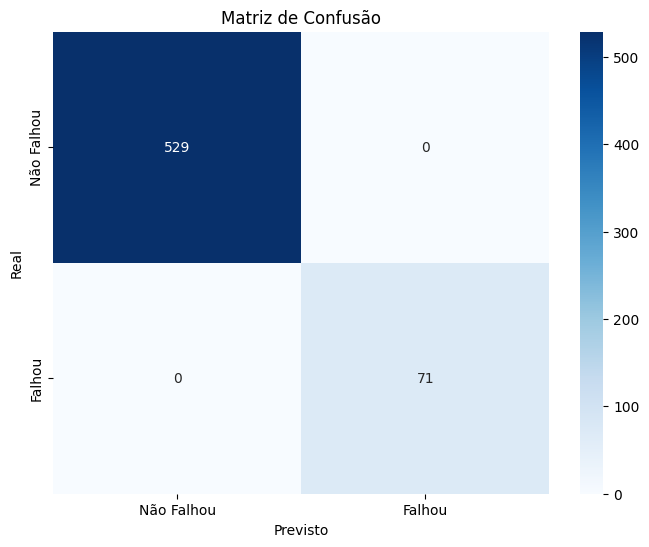

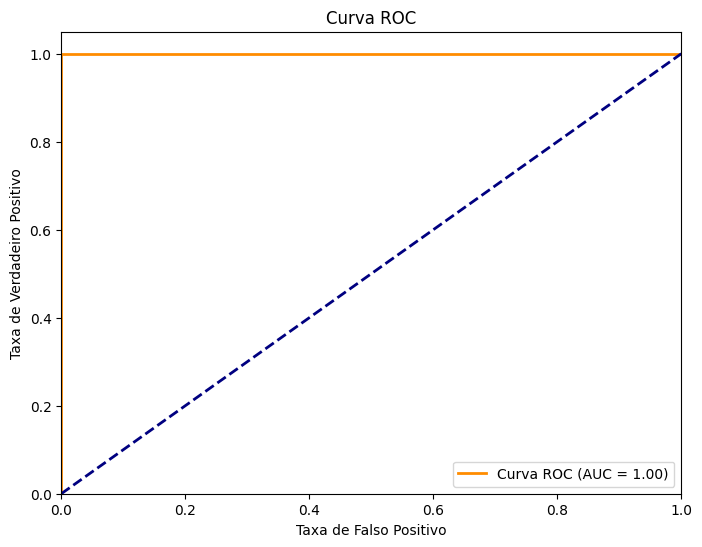

Área Sob a Curva ROC (AUC): 1.00


In [20]:
# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Falhou', 'Falhou'], yticklabels=['Não Falhou', 'Falhou'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# Curva ROC e AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

print(f"Área Sob a Curva ROC (AUC): {roc_auc:.2f}")

### Sumário da Avaliação do Modelo

Conforme o relatório de classificação, o modelo demonstrou um desempenho excepcional, atingindo 100% de precisão, recall e f1-score tanto para a classe 'Não Falhou' (0) quanto para a classe 'Falhou' (1) no conjunto de teste. A Matriz de Confusão confirma que não houve erros de classificação, e a Curva ROC apresenta uma Área Sob a Curva (AUC) de 1.00, indicando uma separação perfeita entre as classes. Este resultado sugere que o modelo é altamente eficaz na previsão de falhas.

### Visualização da Matriz de Confusão

Para uma análise visual dos resultados da classificação, apresentamos a matriz de confusão do modelo no conjunto de teste.

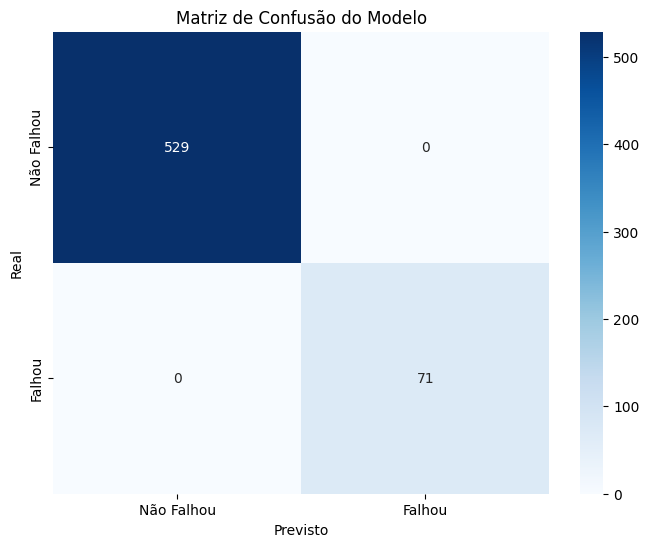

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Recriar a matriz de confusão (garantindo que y_test e y_pred estejam disponíveis)
# y_test e y_pred são gerados no código anterior, então estão disponíveis no kernel
conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Falhou', 'Falhou'], yticklabels=['Não Falhou', 'Falhou'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão do Modelo')
plt.show()

### 3. Otimização da Manutenção e Análise de Importância de Features

Para otimizar a manutenção, é crucial entender quais fatores mais contribuem para a falha da máquina. Vamos extrair a importância das features do modelo treinado.

Para otimizar a manutenção, é crucial entender quais fatores mais contribuem para a falha da máquina. A seguir, visualizamos a importância das features conforme determinado pelo modelo RandomForest:

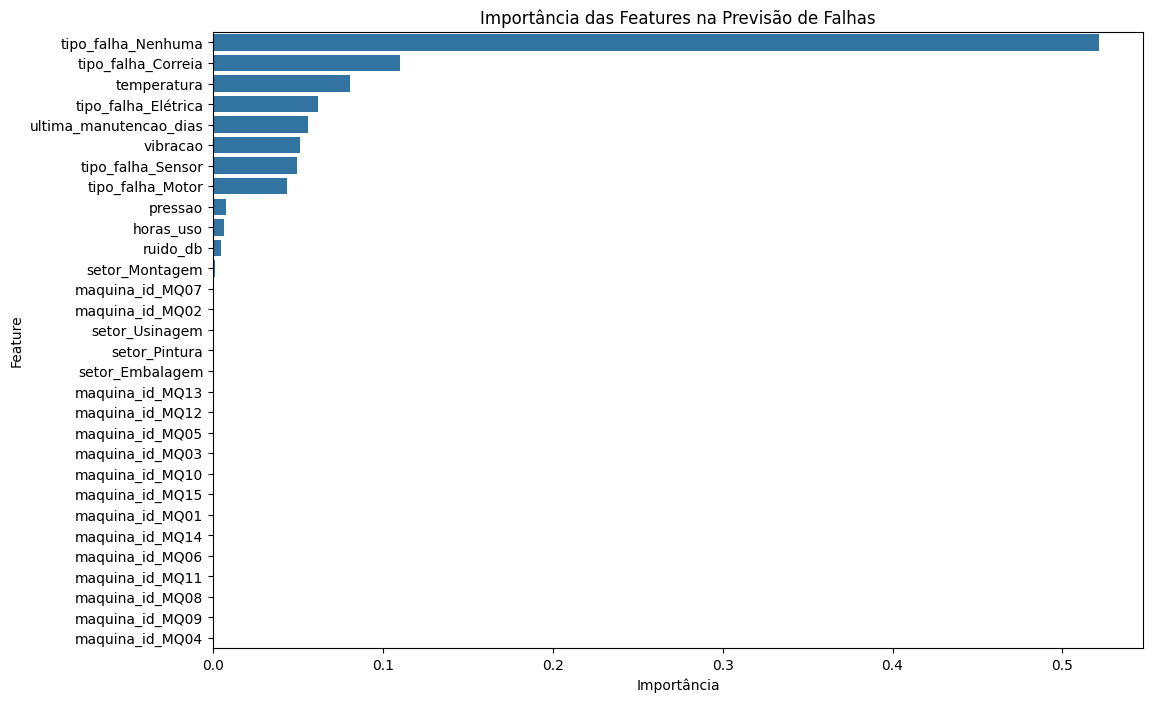

As features mais importantes para prever falhas são:



,Feature,Importance
28,tipo_falha_Nenhuma,0.521382
25,tipo_falha_Correia,0.109942
2,temperatura,0.080468
26,tipo_falha_Elétrica,0.061896
5,ultima_manutencao_dias,0.056091
1,vibracao,0.050912
29,tipo_falha_Sensor,0.049564
27,tipo_falha_Motor,0.043742
3,pressao,0.007680
0,horas_uso,0.006218


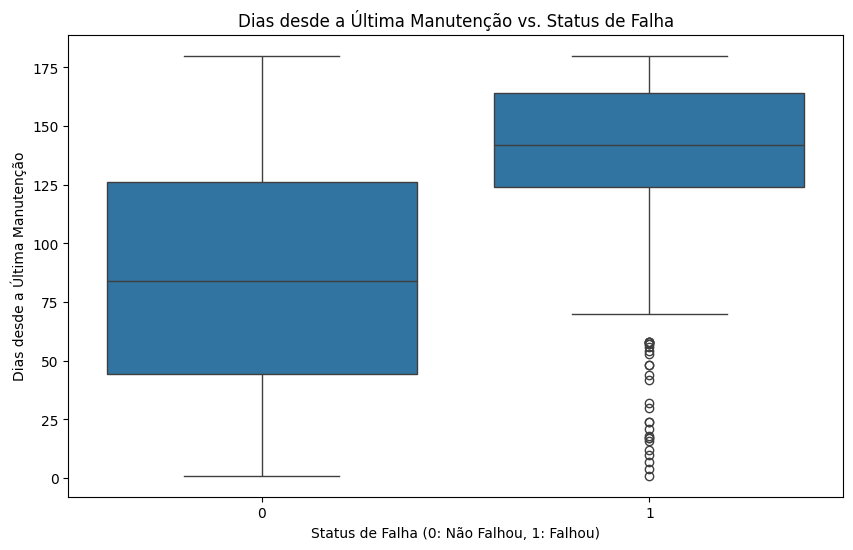


Com base na importância das features e na análise de 'ultima_manutencao_dias', podemos:
- Focar na monitorização das features mais importantes, como 'horas_uso' e 'ultima_manutencao_dias'.
- Considerar a implementação de manutenções preditivas baseadas em limiares dessas features ou em janelas de tempo ideais para 'ultima_manutencao_dias'.


In [21]:
# Obter os nomes das features após o OneHotEncoding
onehot_features = model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = list(numeric_features) + list(onehot_features)

# Obter a importância das features do classificador RandomForest
feature_importances = model.named_steps['classifier'].feature_importances_

# Criar um DataFrame para visualização
importance_df = pd.DataFrame({'Feature': all_features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualizar a importância das features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importância das Features na Previsão de Falhas')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

print("As features mais importantes para prever falhas são:\n")
display(importance_df.head(10))

# Análise de 'ultima_manutencao_dias' em relação à falha
# Podemos analisar a distribuição desta feature para máquinas que falharam vs. não falharam

plt.figure(figsize=(10, 6))
sns.boxplot(x='falhou', y='ultima_manutencao_dias', data=df)
plt.title('Dias desde a Última Manutenção vs. Status de Falha')
plt.xlabel('Status de Falha (0: Não Falhou, 1: Falhou)')
plt.ylabel('Dias desde a Última Manutenção')
plt.show()

print("\nCom base na importância das features e na análise de 'ultima_manutencao_dias', podemos:")
print("- Focar na monitorização das features mais importantes, como 'horas_uso' e 'ultima_manutencao_dias'.")
print("- Considerar a implementação de manutenções preditivas baseadas em limiares dessas features ou em janelas de tempo ideais para 'ultima_manutencao_dias'.")

A análise da importância das features revela que o `tipo_falha_Nenhuma` é a feature mais impactante, o que é esperado, pois máquinas que não falham não possuem um tipo de falha. As falhas do tipo `Correia` e `Elétrica`, juntamente com a `temperatura` e os `dias desde a última manutenção`, são os fatores mais relevantes para a previsão de falhas.

In [24]:
display(importance_df.head(10))

,Feature,Importance
28,tipo_falha_Nenhuma,0.521382
25,tipo_falha_Correia,0.109942
2,temperatura,0.080468
26,tipo_falha_Elétrica,0.061896
5,ultima_manutencao_dias,0.056091
1,vibracao,0.050912
29,tipo_falha_Sensor,0.049564
27,tipo_falha_Motor,0.043742
3,pressao,0.007680
0,horas_uso,0.006218


### Análise de 'Dias desde a Última Manutenção' e seu Impacto nas Falhas

Dado que `ultima_manutencao_dias` é uma das features importantes, vamos analisar mais detalhadamente sua distribuição em relação ao status de falha das máquinas.

/tmp/ipykernel_6435/2363837053.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='falhou', y='ultima_manutencao_dias', data=avg_maintenance_days, palette='coolwarm')


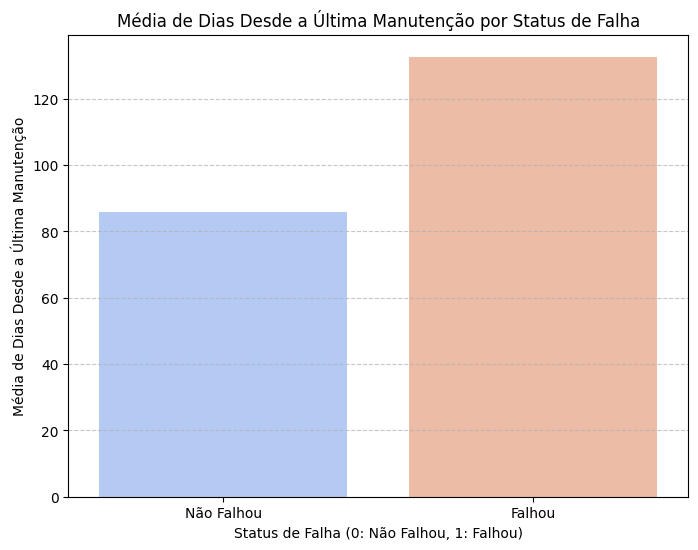

In [23]:
# Calcular a média de 'ultima_manutencao_dias' para máquinas que falharam e não falharam
avg_maintenance_days = df.groupby('falhou')['ultima_manutencao_dias'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='falhou', y='ultima_manutencao_dias', data=avg_maintenance_days, palette='coolwarm')
plt.title('Média de Dias Desde a Última Manutenção por Status de Falha')
plt.xlabel('Status de Falha (0: Não Falhou, 1: Falhou)')
plt.ylabel('Média de Dias Desde a Última Manutenção')
plt.xticks([0, 1], ['Não Falhou', 'Falhou']) # Ajustar os rótulos do eixo x
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Conclusões e Recomendações para Otimização da Manutenção

Os gráficos acima ilustram claramente que máquinas que falham (`falhou=1`) tendem a ter um número significativamente maior de dias desde a última manutenção do que as que não falham (`falhou=0`). A média de dias para máquinas com falha é notavelmente maior. Esta é uma informação crucial para estratégias de manutenção preditiva.

Com base na importância das features e na análise de `ultima_manutencao_dias`, podemos tirar as seguintes conclusões e propor recomendações:

1.  **Foco na Monitorização:** As features mais importantes, como `horas_uso`, `temperatura`, `vibracao` e, principalmente, `ultima_manutencao_dias` devem ser monitorizadas de perto.
2.  **Manutenção Preditiva Baseada em Limiares:** Considerar a implementação de manutenções preditivas baseadas em limiares dessas features. Por exemplo, definir um período máximo para `ultima_manutencao_dias` após o qual uma manutenção preventiva é agendada.
3.  **Priorização de Tipos de Falha:** Dar atenção especial aos tipos de falha 'Correia' e 'Elétrica', que são preditores significativos.
4.  **Otimização do Intervalo de Manutenção:** A diferença notável na média de `ultima_manutencao_dias` entre máquinas que falham e não falham sugere que otimizar os intervalos de manutenção pode reduzir drasticamente as falhas. Isso pode envolver agendamento de manutenções com base em condições ou tempo, em vez de apenas manutenções reativas.